In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import os
from pathlib import Path
import shutil
from datetime import datetime as dt


In [2]:
financial_impact = pd.read_csv("Dados/originais/financial_impact.csv")

In [3]:
def create_bronze_df(df, source_file):
    df_bronze = df.copy()
    df_bronze['_ingestion_timestamp'] = dt.now()
    df_bronze['_source_file'] = source_file
    df_bronze['_week_day'] = df_bronze['_ingestion_timestamp'].day_name()
    return df_bronze

financial_impact_bronze

In [4]:
financial_impact.head(3)

,incident_id,direct_loss_usd,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,total_loss_method,total_loss_lower_bound,total_loss_upper_bound,inflation_adjusted_usd,cpi_index_used,notes,created_at,updated_at
0,2021-0508-001,12600000.00,disclosed,13802654.69,NaN,NaN,9455354.49,2496545.93,90695.25,6756288.97,24642595.67,calculated,15348190.29,4.374658e+07,29237902.75,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2025-1211-001,7640471.18,disclosed,NaN,NaN,NaN,5857150.47,1809188.41,NaN,2691027.33,15306810.06,disclosed,10206030.81,1.890634e+07,15306810.06,CPI-U 2025 (321.5),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2023-0115-001,34881599.59,calculated,NaN,NaN,NaN,26404111.95,10330703.43,NaN,31759649.99,71616414.97,disclosed,60854299.98,1.051520e+08,75564575.92,CPI-U 2023 (304.702),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [5]:
financial_impact.isnull().sum()

incident_id                 0
direct_loss_usd             0
direct_loss_method          0
ransom_demanded_usd       572
ransom_paid_usd           692
ransom_source             692
recovery_cost_usd           0
legal_fees_usd              0
regulatory_fine_usd       646
insurance_payout_usd      343
total_loss_usd              0
total_loss_method           0
total_loss_lower_bound      0
total_loss_upper_bound      0
inflation_adjusted_usd      0
cpi_index_used              0
notes                     530
created_at                  0
updated_at                  0
dtype: int64

In [6]:
financial_impact.info()

<class 'pandas.DataFrame'>
RangeIndex: 778 entries, 0 to 777
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_id             778 non-null    str    
 1   direct_loss_usd         778 non-null    float64
 2   direct_loss_method      778 non-null    str    
 3   ransom_demanded_usd     206 non-null    float64
 4   ransom_paid_usd         86 non-null     float64
 5   ransom_source           86 non-null     str    
 6   recovery_cost_usd       778 non-null    float64
 7   legal_fees_usd          778 non-null    float64
 8   regulatory_fine_usd     132 non-null    float64
 9   insurance_payout_usd    435 non-null    float64
 10  total_loss_usd          778 non-null    float64
 11  total_loss_method       778 non-null    str    
 12  total_loss_lower_bound  778 non-null    float64
 13  total_loss_upper_bound  778 non-null    float64
 14  inflation_adjusted_usd  778 non-null    float64
 15  

In [7]:
financial_impact.describe()

,direct_loss_usd,ransom_demanded_usd,ransom_paid_usd,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,total_loss_lower_bound,total_loss_upper_bound,inflation_adjusted_usd
count,7.780000e+02,2.060000e+02,8.600000e+01,7.780000e+02,7.780000e+02,1.320000e+02,4.350000e+02,7.780000e+02,7.780000e+02,7.780000e+02,7.780000e+02
mean,3.652294e+07,8.017672e+06,4.497464e+06,2.618556e+07,7.309469e+06,2.834303e+06,2.665044e+07,7.099600e+07,5.111886e+07,1.059982e+08,7.501910e+07
std,1.196191e+08,1.580389e+07,9.186802e+06,7.816093e+07,2.390878e+07,7.363815e+06,7.593903e+07,2.151881e+08,1.471999e+08,3.283143e+08,2.233519e+08
min,9.000000e+04,5.000000e+04,1.610098e+04,5.703142e+04,1.276379e+04,5.000000e+04,6.280104e+04,1.737931e+05,1.256943e+05,2.752890e+05,1.737931e+05
25%,2.834239e+06,6.578965e+05,4.247265e+05,2.055169e+06,4.748212e+05,2.771979e+05,2.277000e+06,6.166441e+06,4.519930e+06,8.766029e+06,6.489252e+06
50%,8.525071e+06,1.979266e+06,1.129759e+06,6.129803e+06,1.506969e+06,9.141517e+05,6.316200e+06,1.656491e+07,1.185589e+07,2.534531e+07,1.790865e+07
75%,2.609037e+07,6.303181e+06,3.589926e+06,1.840980e+07,4.756604e+06,2.106179e+06,1.844803e+07,5.259585e+07,3.786537e+07,7.729790e+07,5.589355e+07
max,2.302300e+09,7.500000e+07,5.188418e+07,1.238193e+09,3.828183e+08,5.114644e+07,1.054416e+09,3.451548e+09,2.108922e+09,5.872051e+09,3.451548e+09


In [8]:
financial_impact_bronze = financial_impact.apply(lambda x: create_bronze_df(x, "financial_impact.csv"), axis=1)

In [9]:
if Path("Dados/bronze/financial_impact_bronze.parquet").exists() :
    os.remove('Dados/bronze/financial_impact_bronze.parquet')

In [10]:
Path('Dados/bronze').mkdir(parents=True,exist_ok=True)

In [11]:
financial_impact_bronze.to_parquet('financial_impact_bronze.parquet', compression='snappy')

In [12]:
if Path("Dados/bronze").exists():
    if not (Path("Dados/bronze/financial_impact_bronze.parquet").exists()) :
        financial_impact_bronze.to_parquet('financial_impact_bronze.parquet', compression='snappy')
        shutil.move('financial_impact_bronze.parquet','Dados/bronze')

In [13]:
print(financial_impact_bronze.isnull().sum()/financial_impact_bronze.shape[0] * 100)

incident_id                0.000000
direct_loss_usd            0.000000
direct_loss_method         0.000000
ransom_demanded_usd       73.521851
ransom_paid_usd           88.946015
ransom_source             88.946015
recovery_cost_usd          0.000000
legal_fees_usd             0.000000
regulatory_fine_usd       83.033419
insurance_payout_usd      44.087404
total_loss_usd             0.000000
total_loss_method          0.000000
total_loss_lower_bound     0.000000
total_loss_upper_bound     0.000000
inflation_adjusted_usd     0.000000
cpi_index_used             0.000000
notes                     68.123393
created_at                 0.000000
updated_at                 0.000000
_ingestion_timestamp       0.000000
_source_file               0.000000
_week_day                  0.000000
dtype: float64


<Axes: >

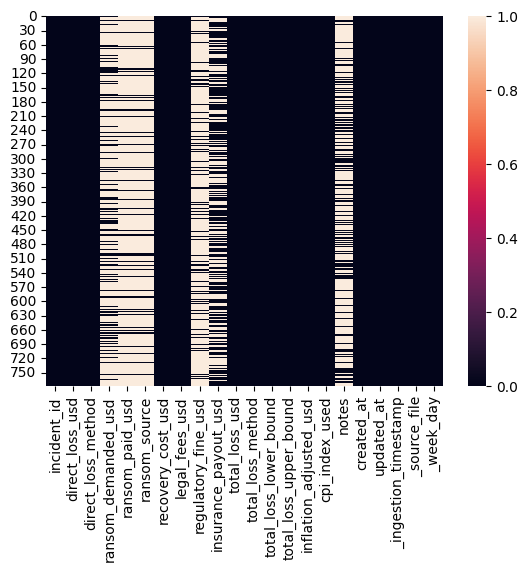

In [14]:
sns.heatmap(financial_impact_bronze.isnull())

In [15]:
print(financial_impact_bronze.duplicated(subset=['incident_id']).value_counts(),financial_impact_bronze.duplicated().sum())

False    778
Name: count, dtype: int64 0


In [16]:
financial_impact_bronze.dtypes

incident_id                          str
direct_loss_usd                  float64
direct_loss_method                   str
ransom_demanded_usd              float64
ransom_paid_usd                  float64
ransom_source                        str
recovery_cost_usd                float64
legal_fees_usd                   float64
regulatory_fine_usd              float64
insurance_payout_usd             float64
total_loss_usd                   float64
total_loss_method                    str
total_loss_lower_bound           float64
total_loss_upper_bound           float64
inflation_adjusted_usd           float64
cpi_index_used                       str
notes                                str
created_at                           str
updated_at                           str
_ingestion_timestamp      datetime64[us]
_source_file                         str
_week_day                            str
dtype: object

In [17]:
financial_impact_prata = financial_impact_bronze.copy()

In [18]:
financial_impact_prata.head(10)

,incident_id,direct_loss_usd,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,...,total_loss_lower_bound,total_loss_upper_bound,inflation_adjusted_usd,cpi_index_used,notes,created_at,updated_at,_ingestion_timestamp,_source_file,_week_day
0,2021-0508-001,12600000.00,disclosed,13802654.69,NaN,NaN,9455354.49,2496545.93,90695.25,6756288.97,...,15348190.29,4.374658e+07,29237902.75,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,2026-04-03 21:22:30.650060,financial_impact.csv,Friday
1,2025-1211-001,7640471.18,disclosed,NaN,NaN,NaN,5857150.47,1809188.41,NaN,2691027.33,...,10206030.81,1.890634e+07,15306810.06,CPI-U 2025 (321.5),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,2026-04-03 21:22:30.652945,financial_impact.csv,Friday
2,2023-0115-001,34881599.59,calculated,NaN,NaN,NaN,26404111.95,10330703.43,NaN,31759649.99,...,60854299.98,1.051520e+08,75564575.92,CPI-U 2023 (304.702),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,2026-04-03 21:22:30.654860,financial_impact.csv,Friday
3,2021-0315-001,4682151.47,disclosed,NaN,NaN,NaN,3642946.48,1029035.85,NaN,1772460.33,...,7648967.81,1.452521e+07,11098475.91,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,2026-04-03 21:22:30.656396,financial_impact.csv,Friday
4,2021-1204-001,2684607.92,estimated,NaN,NaN,NaN,2574871.33,206822.23,NaN,NaN,...,3519806.28,6.755823e+06,6485647.58,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,2026-04-03 21:22:30.657984,financial_impact.csv,Friday
5,2025-0617-001,3735953.80,disclosed,NaN,NaN,NaN,2340266.60,1286207.88,NaN,NaN,...,5604329.75,8.756560e+06,7362428.28,CPI-U 2025 (321.5),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,2026-04-03 21:22:30.659428,financial_impact.csv,Friday
6,2025-0821-001,1700929.83,disclosed,NaN,NaN,NaN,607575.94,313791.90,NaN,NaN,...,1869701.79,3.393272e+06,2622297.67,CPI-U 2025 (321.5),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,2026-04-03 21:22:30.660680,financial_impact.csv,Friday
7,2024-0603-001,1200000.00,disclosed,NaN,NaN,NaN,726046.15,223259.61,NaN,781019.03,...,1646963.50,2.994618e+06,2195817.48,CPI-U 2024 (314.69),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,2026-04-03 21:22:30.662213,financial_impact.csv,Friday
8,2021-0213-001,4864706.42,estimated,NaN,NaN,NaN,1593635.93,1332119.72,NaN,2496437.92,...,5394998.39,1.261305e+07,9243213.48,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,2026-04-03 21:22:30.663407,financial_impact.csv,Friday
9,2025-0529-001,34926502.77,estimated,816664.33,252583.06,insurance claim record,30382641.61,7305976.36,2181266.22,NaN,...,57139339.65,9.351090e+07,75048970.02,CPI-U 2025 (321.5),Insurance claim partially denied; payout refle...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z,2026-04-03 21:22:30.664840,financial_impact.csv,Friday
